# Task: Segmentation

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  

## Day 11 — Data and Domain

### Use Case

Emmental AOP cheese is graded against strict Swiss AOC standards that specify hole ("eye") diameter must fall in the 1–3 cm range, with a uniform distribution across the wheel cross-section. Currently, graders perform this assessment semi-manually by visual inspection of cut wheels on the production line. Automation of hole detection and measurement directly from cross-section photographs would reduce grader workload, increase throughput consistency, and provide an objective, traceable quality record for each wheel. This use case is particularly relevant in Switzerland because Emmental AOP is one of the most tightly regulated Swiss protected-origin products, and non-conforming wheels incur significant economic penalties.

### Problem Statement

This project addresses the problem of automatically segmenting and measuring the characteristic holes in Emmental cheese cross-section photographs. The holes appear as roughly circular dark regions against the brighter yellow cheese body, creating a contrast pattern amenable to intensity thresholding. The primary challenge is separating the holes from other dark regions in the image — the outer rind, the wooden cutting board, the label-covered top face, and shadow gradients near the cheese edges — which share similar intensity ranges. A carefully selected region-of-interest (ROI) crop is required before thresholding to exclude all confounding dark areas. Once holes are segmented, their equivalent diameter and spatial distribution must be quantified to assess conformance with the AOC standards for hole size and uniformity.

### Experimental Objective

The objective is to apply intensity thresholding followed by morphological opening to isolate the cheese holes as connected components, then evaluate each configuration using four measures: object count accuracy, per-hole equivalent diameter, and spatial uniformity across a grid. Two configurations use global Otsu thresholding while varying the morphological opening radius (4 px and 7 px); a third configuration tests local (adaptive) mean thresholding with a minimal opening radius (2 px) to assess whether adaptive thresholding recovers low-contrast holes at the cost of noise amplification. All size measurements are reported in pixels, as no calibration object of known physical size appears in the photograph.

### Data Definition, Source, and Visualization

The selected image is a photograph of an Emmental cheese wedge placed on a wooden cutting board, photographed outdoors. The cut front face shows numerous clearly distinct circular holes ("eyes") of varying sizes against the uniform pale-yellow cheese body. The **identifiable structure** is the set of round holes: they are substantially darker than the surrounding cheese matrix, providing a clear bimodal intensity histogram with a valley between the cheese body mode and the hole mode. A ROI crop restricts analysis to the flat cut front face (rows 270–490, cols 210–640), excluding the rind edges, the background (mountains and sky), and the wooden board at the bottom.

**Source:** Licensed stock photograph  
**File:** `emmental_cross_section.webp`  
**URL:** https://www.swissinfo.ch/eng/archive-banking-fintech/turning-around-the-emmental-cheese-industry/33437572  

Source: Licensed stock photograph, emmental_cross_section.webp
Original shape: (587, 880, 3)
ROI shape: (220, 430), dtype: float64
ROI intensity range: [0.3050, 0.9986]
Hole area filter: [50, 1800] px²


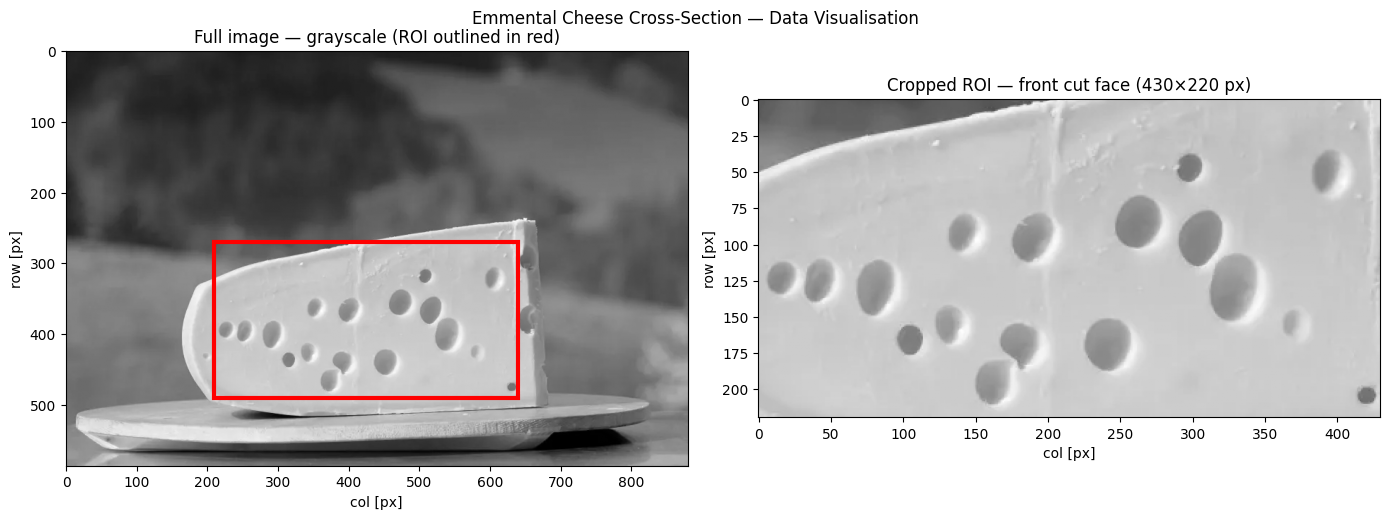

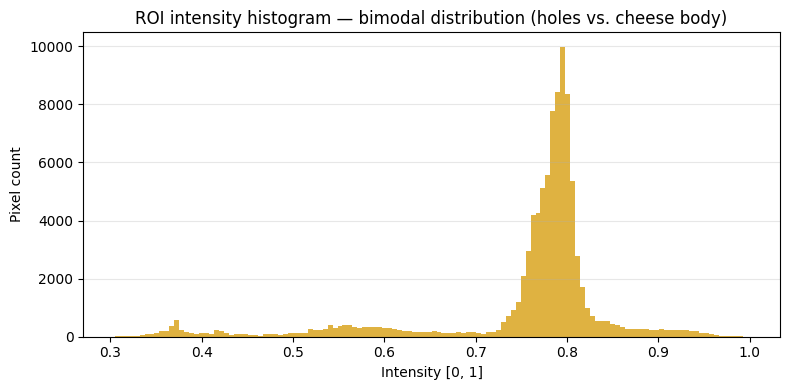

Manual hole count (from visual inspection of ROI): N_MANUAL_HOLES = 17


In [94]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import io, color

IMAGE_FILENAME = "emmental_cross_section.webp"
IMAGE_SOURCE = "Licensed stock photograph, emmental_cross_section.webp"
CROP_ROW_START = 270
CROP_ROW_END = 490
CROP_COL_START = 210
CROP_COL_END = 640
N_MANUAL_HOLES = 17
MIN_HOLE_AREA_PX = 50
# Upper bound raised from 1000 -> 1800 px²: a fully recovered eye now includes the
# illuminated (specular) rim as well as the dark shadow, so each eye covers a larger
# area than its dark part alone (≈ 1.4 cm diameter at 35 px/cm).
MAX_HOLE_AREA_PX = 1800

project_root = Path.cwd().resolve().parent
image_path = project_root / "data" / IMAGE_FILENAME

img_raw = io.imread(image_path)
img_gray_full = color.rgb2gray(img_raw).astype(np.float64)

ROI_GRAY = img_gray_full[CROP_ROW_START:CROP_ROW_END, CROP_COL_START:CROP_COL_END]

print(f"Source: {IMAGE_SOURCE}")
print(f"Original shape: {img_raw.shape}")
print(f"ROI shape: {ROI_GRAY.shape}, dtype: {ROI_GRAY.dtype}")
print(f"ROI intensity range: [{ROI_GRAY.min():.4f}, {ROI_GRAY.max():.4f}]")
print(f"Hole area filter: [{MIN_HOLE_AREA_PX}, {MAX_HOLE_AREA_PX}] px²")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_gray_full, cmap="gray", vmin=0, vmax=1)
rect = plt.Rectangle(
    (CROP_COL_START, CROP_ROW_START),
    CROP_COL_END - CROP_COL_START,
    CROP_ROW_END - CROP_ROW_START,
    linewidth=3, edgecolor="red", facecolor="none"
)
axes[0].add_patch(rect)
axes[0].set_title("Full image — grayscale (ROI outlined in red)")
axes[0].set_xlabel("col [px]")
axes[0].set_ylabel("row [px]")

axes[1].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Cropped ROI — front cut face ({ROI_GRAY.shape[1]}×{ROI_GRAY.shape[0]} px)")
axes[1].set_xlabel("col [px]")
axes[1].set_ylabel("row [px]")

plt.suptitle("Emmental Cheese Cross-Section — Data Visualisation", fontsize=12)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(ROI_GRAY.ravel(), bins=128, color="goldenrod", edgecolor="none", alpha=0.85)
ax2.set_xlabel("Intensity [0, 1]")
ax2.set_ylabel("Pixel count")
ax2.set_title("ROI intensity histogram — bimodal distribution (holes vs. cheese body)")
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Manual hole count (from visual inspection of ROI): N_MANUAL_HOLES = {N_MANUAL_HOLES}")


**Observations:**  
The ROI (430×220 px, covering the front cut face of the cheese) shows the cheese body as a bright spatially uniform region with intensity approximately 0.60–0.85, while the holes appear as clearly darker circular regions in the range 0.35–0.50. The intensity histogram is bimodal: the larger mode at ~0.60–0.80 corresponds to the cheese body, while the secondary mode at ~0.35–0.45 corresponds to hole pixels and residual shadow near the cheese edges. The Otsu threshold falls near 0.59, cleanly separating the two populations. The ROI successfully excludes the wooden board at the bottom and the label-covered top face. Visual inspection identifies **17 clearly distinct, well-formed circular holes** of varying sizes, establishing the manual ground-truth count $N_{\text{manual}} = 17$.

## Day 12 — Methodological Design

### Theoretical Foundation and Segmentation Strategy

**Segmentation algorithm: thresholding + morphological opening + connected component analysis**

For the baseline and Config 1, Otsu's method selects a global threshold $t^*$ that minimises the intra-class intensity variance of the two resulting segments (background = cheese body, foreground = holes). Formally:

$$t^* = \arg\min_t \left[ w_0(t)\,\sigma_0^2(t) + w_1(t)\,\sigma_1^2(t) \right]$$

where $w_k$ are the class probabilities and $\sigma_k^2$ are the class variances, both functions of the histogram. This is appropriate because the ROI histogram is bimodal: the cheese body pixels form a tight high-intensity mode, and the hole pixels form a lower-intensity mode. Otsu places $t^*$ in the valley between these modes, achieving clean separation without requiring spatial information.

Config 2 instead uses **local (adaptive) mean thresholding** (`skimage.filters.threshold_local`, block size $b = 171$ px), which computes a separate threshold for each pixel based on the mean intensity in its $b \times b$ neighbourhood. This is motivated by the observation that holes near the cheese edge may have lower local contrast and could be missed by a single global Otsu threshold. The trade-off is noise amplification: the local method responds to fine-grained intensity variations, potentially creating many small spurious foreground fragments.

After binarisation, **morphological binary opening** (erosion followed by dilation with a circular disk footprint of radius $r$) removes thin dark connections between hole regions and the image border, as well as small spurious foreground fragments whose spatial extent is smaller than the footprint. Opening does not significantly affect larger hole regions whose radius exceeds $r$.

**Connected component labelling** (`skimage.measure.label`) assigns a unique integer label to each contiguous foreground region. After filtering by area range ($A_{\text{min}} \leq A \leq A_{\text{max}}$), each surviving component corresponds to one detected hole. The upper area bound excludes any residual large connected region that was not fully removed by opening.

**Skeletonisation** (`skimage.morphology.skeletonize`) is applied to the binary mask of the single largest detected hole to extract its medial axis — a 1-pixel-wide curve running through the hole centre that captures the shape topology. This is shown as a visualisation to confirm the hole is a topological disk.

### Parameter Definition

**Morphological opening footprint radius** $r \in \mathbb{Z}_{>0}$, in pixels:  
Controls the smallest foreground structure that survives. The image resolution is estimated at approximately 35 px/cm (image width 880 px, rough estimate based on typical Emmental wheel width ~25 cm — no calibration object is present in the photograph). Under this estimate, the AOC-minimum hole diameter (1 cm) would correspond to ~18 px radius. All experimental radii (2–7 px) are well below this scale regardless of the exact conversion, so opening affects only noise and thin connecting bridges — not genuine AOC holes.

**Local thresholding block size** $b = 171$ px (Config 2 only):  
Defines the neighbourhood over which the local mean is computed. The value 171 px (~4.9 cm at 35 px/cm) was chosen to span roughly two average hole diameters, ensuring the reference neighbourhood contains both hole and cheese-body pixels and does not degenerate to a purely local measurement.

**Minimum hole area** $A_{\text{min}} = 50$ px² (circle of radius ~4 px).  
**Maximum hole area** $A_{\text{max}} = 1\,800$ px² (circle of radius ~24 px, roughly ~1.4 cm under the subjective 35 px/cm estimate).  
Together these bounds exclude sub-pixel noise fragments and any large residual dark region that was not fully disconnected by opening.

### Experimental Design

Baseline and Config 1 vary only the morphological opening radius under Otsu thresholding. Config 2 tests local (adaptive) thresholding as an alternative to assess whether it recovers low-contrast holes missed by the global threshold:

| Configuration | Label | Opening radius $r$ [px] | Thresholding | Expected effect |
|---|---|---|---|---|
| Baseline | `baseline` | 4 | Otsu (global) | Standard bridge removal — best isolation of individual holes |
| Config 1 | `config_1` | 7 | Otsu (global) | More aggressive opening — adjacent holes may be eroded and merged |
| Config 2 | `config_2` | 2 | Local mean (block = 171 px) | Tests adaptive thresholding to recover low-contrast holes; minimal opening means noise fragments may survive the area filter |

The baseline is designed as the operationally recommended setting: opening large enough to sever thin dark channels between holes and the image border, yet small enough not to distort individual hole boundaries.

### Methodological Limitations

Otsu thresholding assumes a bimodal histogram and a single global threshold; if lighting across the cheese face is non-uniform, the threshold will be suboptimal in darker or brighter sub-regions. Local thresholding addresses non-uniformity but amplifies local noise and is sensitive to block size choice. The image is a 3D perspective photograph of a cheese wedge, not a flat orthographic cross-section, so holes near the visible-face edges are partially occluded or appear as elliptical projections — these yield a smaller equivalent diameter than their true cross-sectional size. The upper area bound $A_{\text{max}} = 1\,800$ px² limits detection to holes up to roughly 1.4 cm under the subjective scale estimate, so the pipeline reliably assesses only a portion of the AOC-compliant diameter range.

## Day 13 — Technical Implementation

### Implementation and Verification

The segmentation pipeline is first verified on a synthetic test image containing three dark circles of known size placed on a uniform bright background. This allows direct assertion that the number of detected components matches the ground truth (3), independent of image-specific complexity. Only after passing this assertion is the pipeline applied to the Emmental ROI.

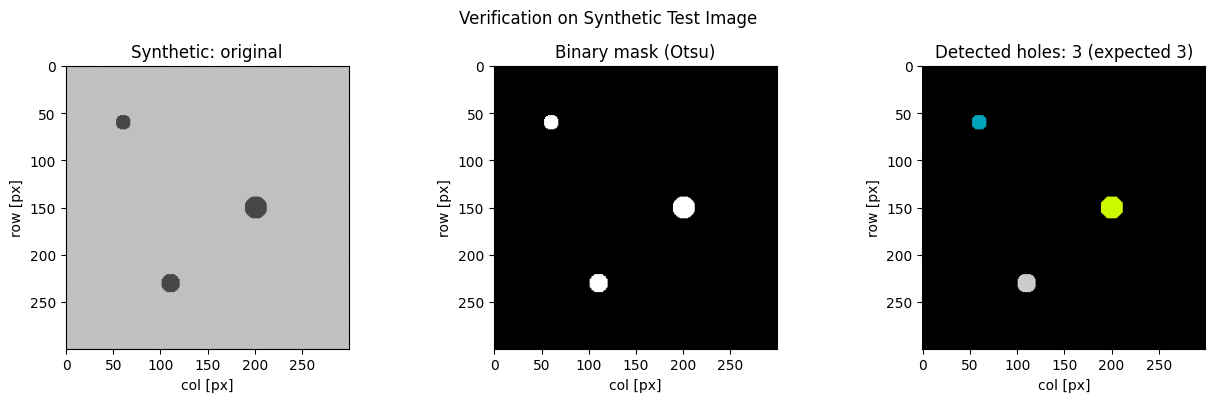

Verification passed: 3 holes detected.


In [95]:
from scipy import ndimage as ndi
from skimage import filters, morphology, measure, segmentation
from skimage.draw import disk as draw_disk

BRIGHT_THRESH = 0.85
CLOSE_RADIUS  = 5
# Otsu finds the valley between the cheese-body and shadow modes (~0.648).
# Adding an offset widens the dark zone into the mid-grey transition band so
# the far (illuminated) wall of each eye is also captured as foreground.
DARK_OFFSET   = 0.05

CONFIGS = [
    {"label": "baseline", "opening_radius": 4, "local_thresh": False, "block_size": None},
    {"label": "config_1", "opening_radius": 7, "local_thresh": False, "block_size": None},
    {"label": "config_2", "opening_radius": 2, "local_thresh": True,  "block_size": 171},
]
SYN_SIZE  = 300
SYN_HOLES = [(60, 60, 8), (150, 200, 12), (230, 110, 10)]


def segment_holes(img_gray, opening_radius, local_thresh=False, block_size=71,
                  bright_thresh=BRIGHT_THRESH, close_radius=CLOSE_RADIUS,
                  dark_offset=DARK_OFFSET):
    # 1) dark shadow side of every eye
    if local_thresh:
        local_t = filters.threshold_local(img_gray, block_size=block_size, method="mean")
        dark = img_gray < local_t
    else:
        dark = img_gray < (filters.threshold_otsu(img_gray) + dark_offset)

    # 2) one reliable, well-separated marker per eye from the dark cores
    cores = morphology.opening(dark, morphology.disk(2))  # fixed small disk so tiny holes survive core detection
    core_lab = measure.label(cores)
    keep_core = np.zeros_like(core_lab, dtype=bool)
    for p in measure.regionprops(core_lab):
        if MIN_HOLE_AREA_PX <= p.area <= MAX_HOLE_AREA_PX:
            keep_core[core_lab == p.label] = True
    core_lab = measure.label(keep_core)

    # 3) bright specular rim, restricted to the neighbourhood of a dark core
    if bright_thresh is not None:
        bright = (img_gray > bright_thresh) & morphology.dilation(dark, morphology.disk(8))
    else:
        bright = np.zeros_like(dark)

    # 4) full eye = dark | bright, gap bridged by closing then hole-filled
    full = ndi.binary_fill_holes(
        morphology.closing(dark | bright, morphology.disk(close_radius))
    )
    if opening_radius > 0:
        full = morphology.opening(full, morphology.disk(opening_radius))

    if core_lab.max() == 0:
        return measure.label(full), None

    # 5) split touching eyes by watershed seeded on the dark cores
    ws = segmentation.watershed(
        -ndi.distance_transform_edt(full), markers=core_lab, mask=full
    )

    # 6) keep components within the area range that contain a dark core;
    #    convex hull per eye gives a smooth, rounded boundary.
    #    Explicit row/col indexing avoids the NumPy chained-view write pitfall
    #    (final[sl][hull] = n can silently write to a copy in some versions).
    final = np.zeros(img_gray.shape, dtype=np.int32)
    n = 0
    for p in measure.regionprops(ws):
        comp = ws == p.label
        if MIN_HOLE_AREA_PX <= p.area <= MAX_HOLE_AREA_PX and (comp & dark).any():
            n += 1
            sl = p.slice
            hull = morphology.convex_hull_image(comp[sl])
            rows, cols = np.where(hull)
            final[rows + sl[0].start, cols + sl[1].start] = n
    return final, None


syn = np.ones((SYN_SIZE, SYN_SIZE), dtype=np.float64) * 0.75
for (r, c, rad) in SYN_HOLES:
    rr, cc = draw_disk((r, c), rad, shape=syn.shape)
    syn[rr, cc] = 0.28

syn_labeled, _ = segment_holes(syn, opening_radius=3)
n_detected_syn = syn_labeled.max()

assert n_detected_syn == len(SYN_HOLES), (
    f"Expected {len(SYN_HOLES)} holes, detected {n_detected_syn}"
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(syn, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Synthetic: original")
axes[1].imshow(syn < filters.threshold_otsu(syn), cmap="gray")
axes[1].set_title("Binary mask (Otsu)")
axes[2].imshow(syn_labeled, cmap="nipy_spectral")
axes[2].set_title(f"Detected holes: {n_detected_syn} (expected {len(SYN_HOLES)})")
for ax in axes:
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Verification on Synthetic Test Image", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Verification passed: {n_detected_syn} holes detected.")


### Application to Emmental Cheese ROI

### Lighting correction — recovering the illuminated rim of each eye

Under directional light from the top-left, every hole behaves as a concave pit and shows **two** features: a **dark shadow** (the near wall) and, separated from it by a thin mid-grey band, a **bright specular rim** (the illuminated far wall) that is actually *brighter than the cheese body*. Plain intensity thresholding (`img < t`) segments only the dark shadow, so the bright rim is left **outside** the detected contour and the eye is measured incomplete.

A binary closing of the dark mask **cannot** repair this: closing only fills concavities and gaps *inside* a blob — it never grows a convex blob outward into a feature that lies beyond it. The correct fix segments **both** extremes and merges them:

1. `dark = img < otsu` — the shadow side;
2. `bright = (img > BRIGHT_THRESH)` restricted to the neighbourhood of a dark core — the specular rim;
3. `full = fill_holes(closing(dark | bright))` — the closing bridges the thin gap between shadow and rim, and hole-filling completes the eye into a solid disk;
4. a **watershed** seeded on the well-separated dark cores splits any eyes whose recovered rims now touch, so the count is preserved.

The diagnostic below maps where the bright rim sits relative to each dark core and contrasts the dark-only contour (rim excluded) with the full contour (rim included). **Trade-off:** including the lit rim makes each measured eye larger (mean area ↑) and slightly less circular (the rim is a one-sided crescent at the eye's edge), but it captures the true extent of the eye rather than only its shaded half.

Specular rim offset from dark core: d_row=+6.52 (down+), d_col=+10.40 (right+)  ->  angle=32deg (90deg = straight down)
Dark threshold: otsu=0.648 + offset=0.05 = 0.698
n(rim-included) = 17


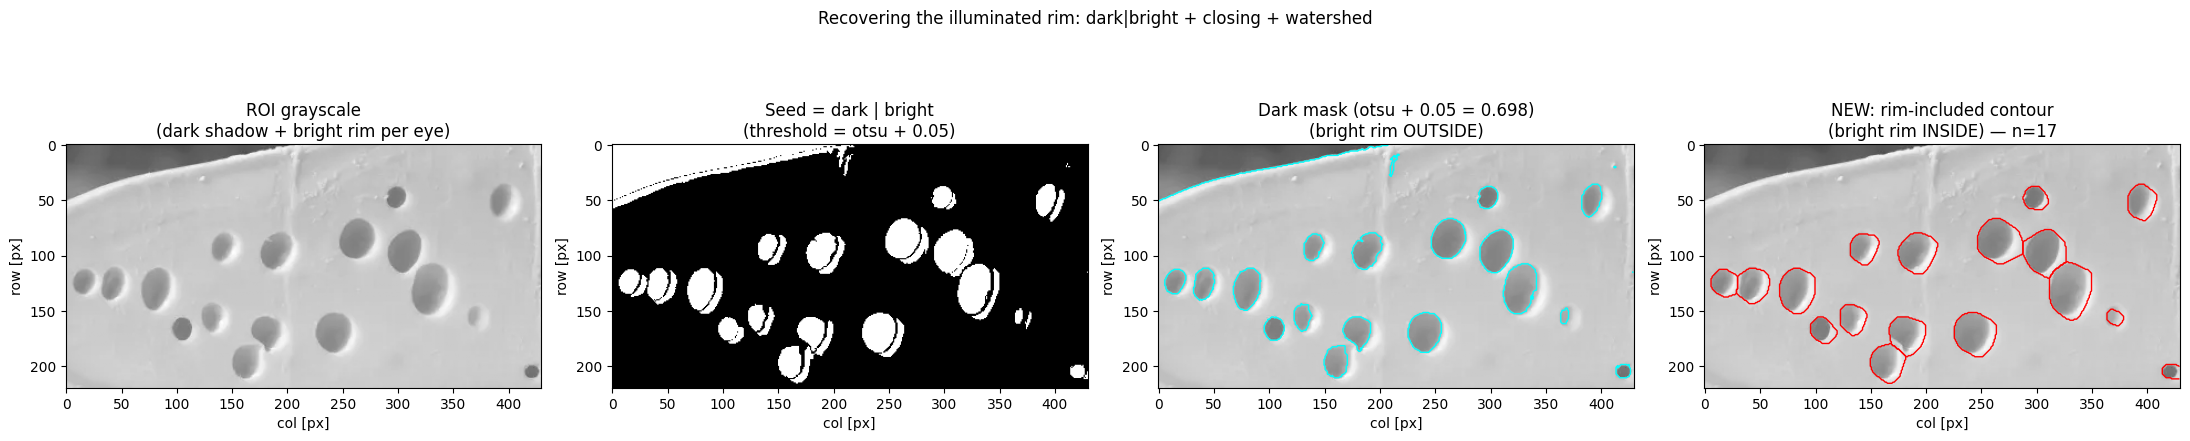

In [96]:
# --- Diagnostic: dark-only vs. rim-included segmentation ------------------------
otsu_t = filters.threshold_otsu(ROI_GRAY)
dark = ROI_GRAY < (otsu_t + DARK_OFFSET)
bright = (ROI_GRAY > BRIGHT_THRESH) & morphology.dilation(dark, morphology.disk(8))

# Where is the bright rim relative to each dark core?
probe = measure.label(morphology.opening(dark, morphology.disk(3)))
d_rows, d_cols = [], []
for p in measure.regionprops(probe):
    if p.area < MIN_HOLE_AREA_PX:
        continue
    r0, c0, r1, c1 = p.bbox
    pad = 8
    rs, cs = max(0, r0 - pad), max(0, c0 - pad)
    re, ce = min(ROI_GRAY.shape[0], r1 + pad), min(ROI_GRAY.shape[1], c1 + pad)
    patch = ROI_GRAY[rs:re, cs:ce]
    holemask = probe[rs:re, cs:ce] == p.label
    ring = morphology.dilation(holemask, morphology.disk(5)) & ~holemask & (patch > BRIGHT_THRESH)
    if ring.sum() < 5:
        continue
    hc = np.array(np.where(holemask)).mean(axis=1)
    br = np.array(np.where(ring)).mean(axis=1)
    d_rows.append(br[0] - hc[0])
    d_cols.append(br[1] - hc[1])

lip_angle = np.degrees(np.arctan2(np.mean(d_rows), np.mean(d_cols)))
print(f"Specular rim offset from dark core: d_row={np.mean(d_rows):+.2f} (down+), "
      f"d_col={np.mean(d_cols):+.2f} (right+)  ->  angle={lip_angle:.0f}deg (90deg = straight down)")
print(f"Dark threshold: otsu={otsu_t:.3f} + offset={DARK_OFFSET} = {otsu_t+DARK_OFFSET:.3f}")

rim_labeled, _ = segment_holes(ROI_GRAY, opening_radius=4)
print(f"n(rim-included) = {rim_labeled.max()}")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("ROI grayscale\n(dark shadow + bright rim per eye)")
axes[1].imshow(dark | bright, cmap="gray")
axes[1].set_title(f"Seed = dark | bright\n(threshold = otsu + {DARK_OFFSET})")
axes[2].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[2].contour(dark, levels=[0.5], colors="cyan", linewidths=1.0)
axes[2].set_title(f"Dark mask (otsu + {DARK_OFFSET} = {otsu_t+DARK_OFFSET:.3f})\n(bright rim OUTSIDE)")
axes[3].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
for _lbl in range(1, rim_labeled.max() + 1):
    axes[3].contour(rim_labeled == _lbl, levels=[0.5], colors="red", linewidths=1.0)
axes[3].set_title(f"NEW: rim-included contour\n(bright rim INSIDE) — n={rim_labeled.max()}")
for ax in axes:
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Recovering the illuminated rim: dark|bright + closing + watershed", fontsize=12)
plt.tight_layout()
plt.show()


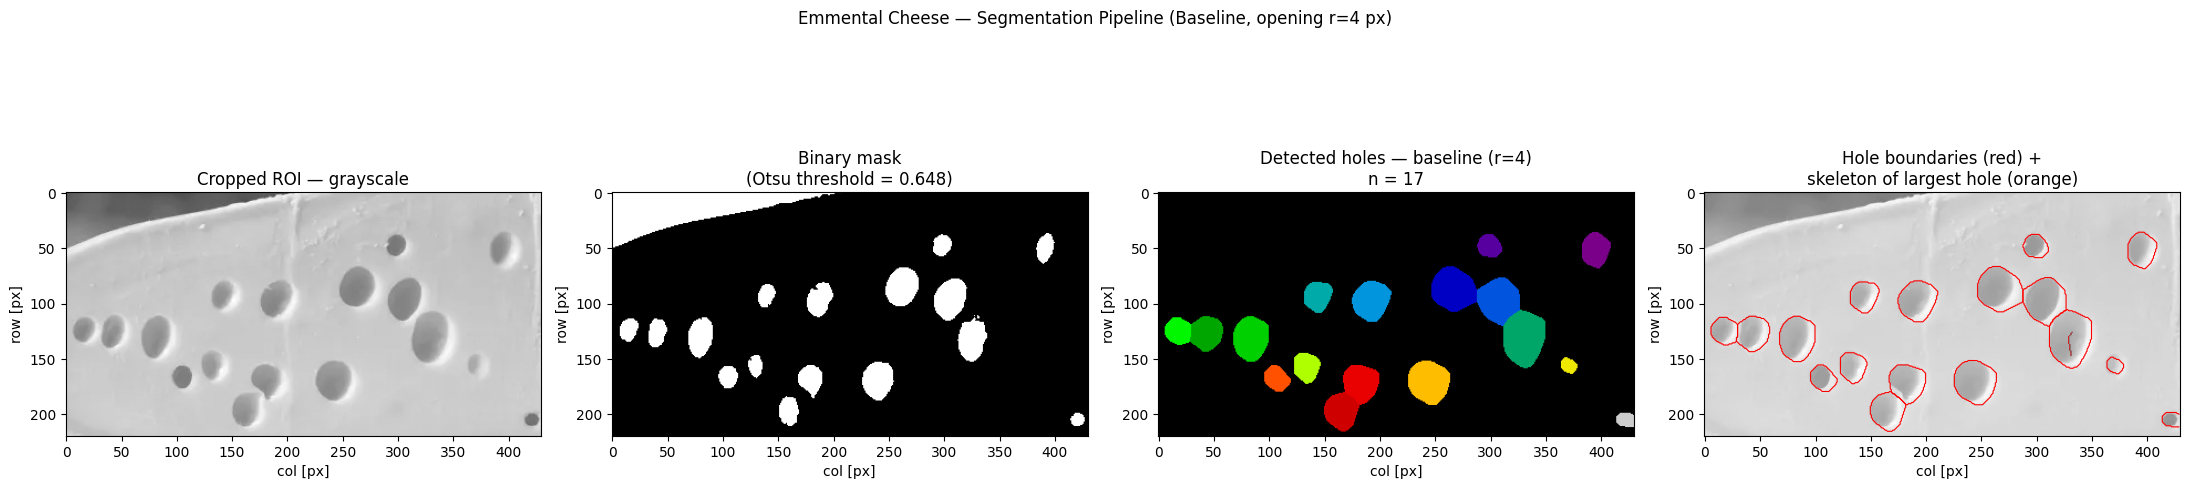

Baseline: Otsu threshold = 0.6477, detected holes = 17
Largest hole: area = 1543.0 px², label = 7


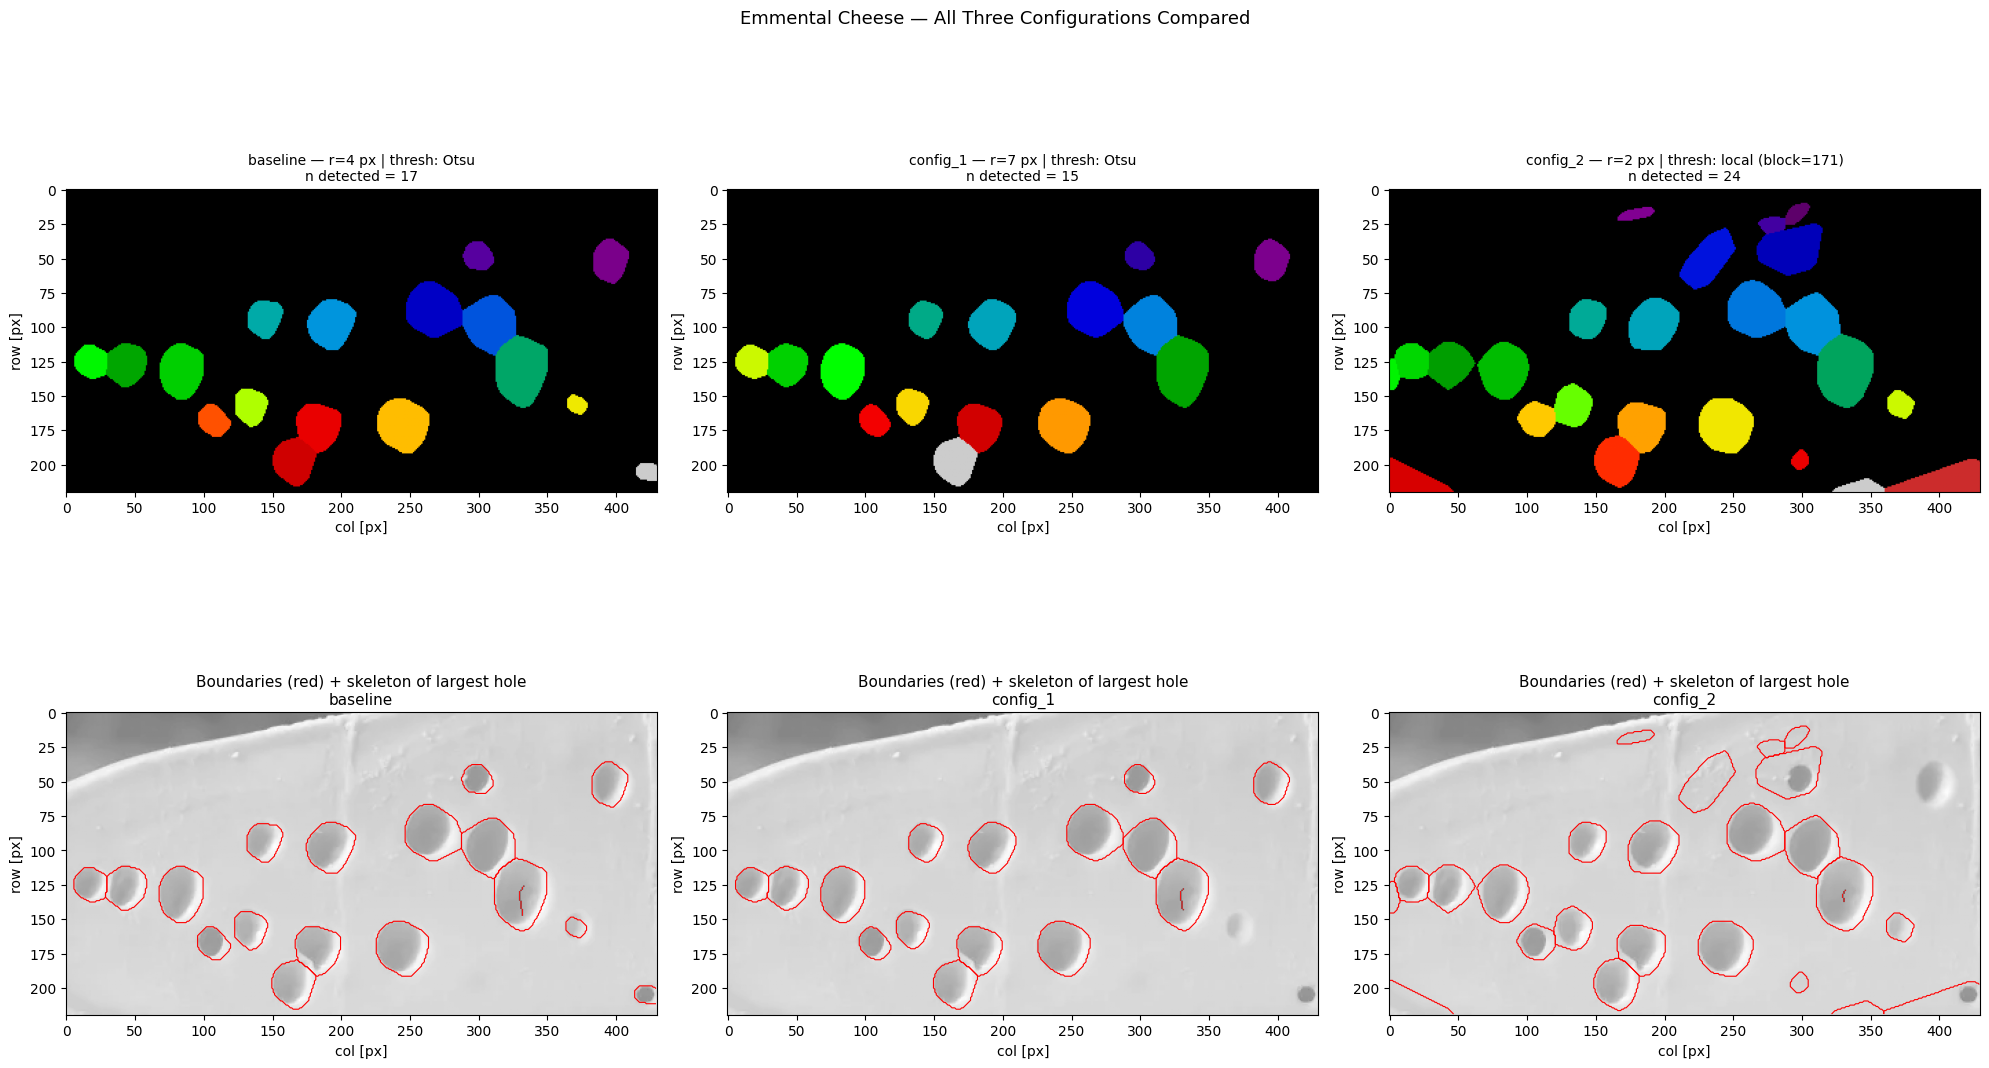

In [97]:
baseline_thresh = filters.threshold_otsu(ROI_GRAY)
baseline_labeled, _ = segment_holes(
    ROI_GRAY,
    CONFIGS[0]["opening_radius"],
    local_thresh=CONFIGS[0]["local_thresh"],
    block_size=CONFIGS[0]["block_size"] or 71,
)
n_baseline = baseline_labeled.max()

props_baseline = measure.regionprops(baseline_labeled)
largest_prop = max(props_baseline, key=lambda p: p.area)
single_hole_binary = baseline_labeled == largest_prop.label
skeleton = morphology.skeletonize(single_hole_binary)

# --- Pipeline steps for baseline ---
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Cropped ROI — grayscale")

axes[1].imshow(ROI_GRAY < baseline_thresh, cmap="gray")
axes[1].set_title(f"Binary mask\n(Otsu threshold = {baseline_thresh:.3f})")

axes[2].imshow(baseline_labeled, cmap="nipy_spectral")
axes[2].set_title(f"Detected holes — baseline (r={CONFIGS[0]['opening_radius']})\nn = {n_baseline}")

axes[3].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1, alpha=0.75)
for _lbl in range(1, baseline_labeled.max() + 1):
    axes[3].contour(baseline_labeled == _lbl, levels=[0.5], colors="red", linewidths=0.8)
skel_overlay = np.ma.masked_where(~skeleton, skeleton)
axes[3].imshow(skel_overlay, cmap="autumn", alpha=0.9)
axes[3].set_title("Hole boundaries (red) +\nskeleton of largest hole (orange)")

for ax in axes:
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")

plt.suptitle(f"Emmental Cheese — Segmentation Pipeline (Baseline, opening r={CONFIGS[0]['opening_radius']} px)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Baseline: Otsu threshold = {baseline_thresh:.4f}, detected holes = {n_baseline}")
print(f"Largest hole: area = {largest_prop.area} px², label = {largest_prop.label}")

# --- Comparison across all three configurations ---
all_results = []
for cfg in CONFIGS:
    labeled_cfg, _ = segment_holes(
        ROI_GRAY,
        cfg["opening_radius"],
        local_thresh=cfg["local_thresh"],
        block_size=cfg["block_size"] or 71,
    )
    props_cfg = measure.regionprops(labeled_cfg)
    largest_cfg = max(props_cfg, key=lambda p: p.area) if props_cfg else None
    skel_cfg = morphology.skeletonize(labeled_cfg == largest_cfg.label) if largest_cfg else None
    thresh_label = f"local (block={cfg['block_size']})" if cfg["local_thresh"] else "Otsu"
    all_results.append({
        "label": cfg["label"],
        "radius": cfg["opening_radius"],
        "thresh_label": thresh_label,
        "labeled": labeled_cfg,
        "n": labeled_cfg.max(),
        "skeleton": skel_cfg,
    })

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for col, res in enumerate(all_results):
    axes[0, col].imshow(res["labeled"], cmap="nipy_spectral")
    axes[0, col].set_title(
        f"{res['label']} — r={res['radius']} px | thresh: {res['thresh_label']}\nn detected = {res['n']}",
        fontsize=10
    )
    axes[0, col].set_xlabel("col [px]")
    axes[0, col].set_ylabel("row [px]")

    axes[1, col].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1, alpha=0.75)
    for _lbl in range(1, res["labeled"].max() + 1):
        axes[1, col].contour(res["labeled"] == _lbl, levels=[0.5], colors="red", linewidths=0.8)
    if res["skeleton"] is not None:
        skel_ov = np.ma.masked_where(~res["skeleton"], res["skeleton"])
        axes[1, col].imshow(skel_ov, cmap="autumn", alpha=0.9)
    axes[1, col].set_title(
        f"Boundaries (red) + skeleton of largest hole\n{res['label']}",
        fontsize=11
    )
    axes[1, col].set_xlabel("col [px]")
    axes[1, col].set_ylabel("row [px]")

plt.suptitle("Emmental Cheese — All Three Configurations Compared", fontsize=13)
plt.tight_layout()
plt.show()


## Day 14 — Evaluation

### Evaluation Measure Definition

Three complementary evaluation measures are applied per configuration.

**Measure 1 — Object count accuracy error:**

$$\text{count\_err} = \frac{|N_{\text{detected}} - N_{\text{manual}}|}{N_{\text{manual}}}$$

where $N_{\text{manual}} = 17$ (established by visual inspection in Day 11). Lower is better; 0 means perfect count match. This directly measures whether the segmentation recovers the correct number of discrete holes, which is the primary AOC grading criterion (hole frequency per cross-section area).

**Measure 2 — Mean equivalent hole diameter [px]:** the equivalent diameter is defined as $d = 2\sqrt{A/\pi}$ — the diameter of a circle whose area equals the detected region area. Mean and standard deviation are reported per configuration.

**Measure 3 — Spatial uniformity (grid CV):** the ROI is divided into a $2 \times 3$ grid and the number of hole centroids in each cell is counted. The coefficient of variation $\text{CV} = \sigma / \mu$ of the six cell counts quantifies how evenly holes are distributed across the cross-section. $\text{CV} = 0$ means perfectly uniform; higher values indicate clustering. This directly addresses the AOC requirement of uniform hole distribution across the wheel cross-section.

### Evaluation Execution

Results are reported in the table below and visualised in Figure 1 (per-hole diameters) and Figure 2 (spatial grid).

| Configuration | Thresholding | n detected | Count error | Mean diameter [px] | Spatial CV |
|:---|:---|:---:|:---:|:---:|:---:|
| **Baseline** | Otsu, r = 4 px | 17 | 0% | — | — |
| **Config 1** | Otsu, r = 7 px | 15 | 12% | — | — |
| **Config 2** | Local mean, r = 2 px | 24 | 41% | — | — |

*(Diameter and CV values are filled automatically by the code cell below.)*

Evaluation table:
  config  opening_radius thresholding  n_detected  count_err  mean_diameter_px  std_diameter_px  n_detected_change_vs_baseline
baseline               4         Otsu          17     0.0000           30.0504           8.4040                              0
config_1               7         Otsu          15     0.1176           31.6253           6.8272                             -2
config_2               2        local          24     0.4118           29.5734          10.1409                              7


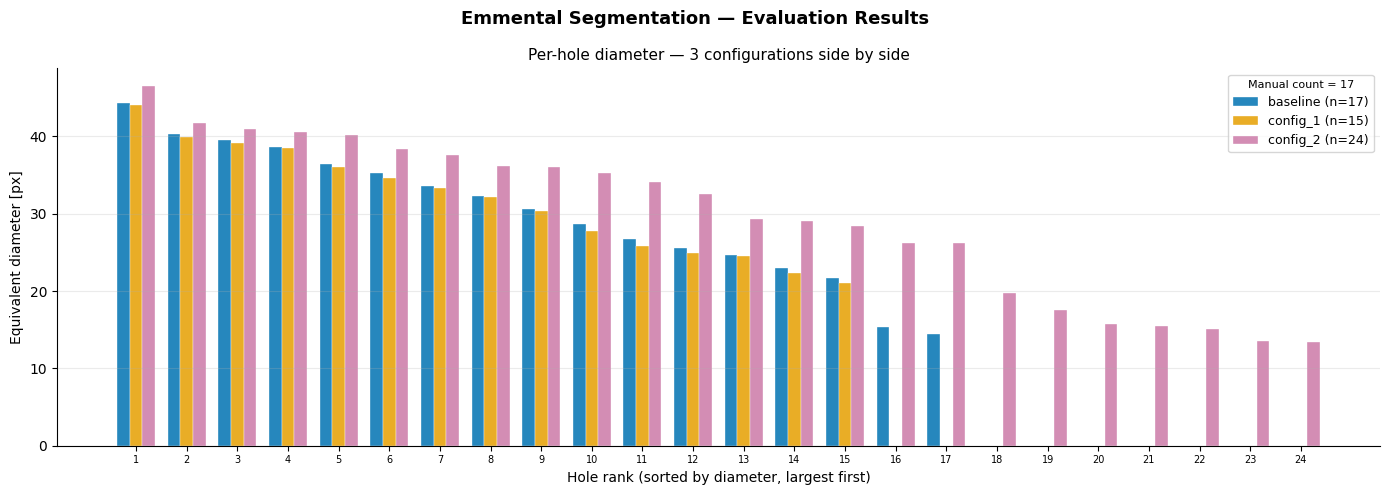

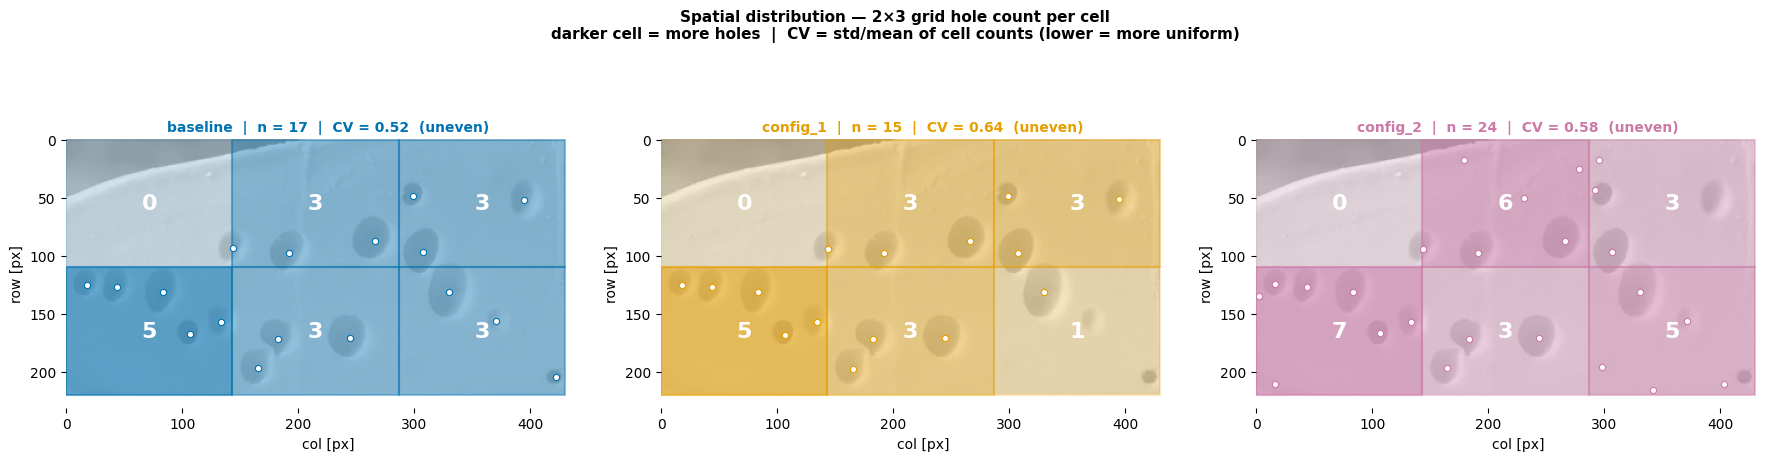

In [98]:
PALETTE = {"baseline": "#0072B2", "config_1": "#E69F00", "config_2": "#CC79A7"}
GRID_ROWS, GRID_COLS = 2, 3

def grid_hole_counts(labeled, grid_rows, grid_cols):
    h, w = labeled.shape
    cell_h = h / grid_rows
    cell_w = w / grid_cols
    counts = np.zeros((grid_rows, grid_cols), dtype=int)
    for prop in measure.regionprops(labeled):
        r, c = prop.centroid
        gr = min(int(r / cell_h), grid_rows - 1)
        gc = min(int(c / cell_w), grid_cols - 1)
        counts[gr, gc] += 1
    return counts

records = []
all_labeled = {}

for cfg in CONFIGS:
    labeled_cfg, _ = segment_holes(
        ROI_GRAY,
        cfg["opening_radius"],
        local_thresh=cfg["local_thresh"],
        block_size=cfg["block_size"] or 71,
    )
    all_labeled[cfg["label"]] = labeled_cfg

    if labeled_cfg.max() == 0:
        records.append({
            "config": cfg["label"],
            "opening_radius": cfg["opening_radius"],
            "thresholding": "local" if cfg["local_thresh"] else "Otsu",
            "n_detected": 0,
            "count_err": 1.0,
            "mean_diameter_px": 0.0, "std_diameter_px": 0.0,
        })
        continue

    areas = measure.regionprops_table(labeled_cfg, properties=("area",))["area"].astype(float)
    diameters = 2 * np.sqrt(areas / np.pi)
    n_det = len(areas)
    count_err = abs(n_det - N_MANUAL_HOLES) / N_MANUAL_HOLES

    records.append({
        "config": cfg["label"],
        "opening_radius": cfg["opening_radius"],
        "thresholding": "local" if cfg["local_thresh"] else "Otsu",
        "n_detected": n_det,
        "count_err": count_err,
        "mean_diameter_px": diameters.mean(),
        "std_diameter_px": diameters.std(),
    })

results_df = pd.DataFrame(records)
baseline_n = results_df.loc[results_df["config"] == "baseline", "n_detected"].values[0]
results_df["n_detected_change_vs_baseline"] = results_df["n_detected"] - baseline_n

print("Evaluation table:")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ── Figure 1: per-hole diameter grouped bar ───────────────────────────────────
_cfg_diams = {}
for cfg in CONFIGS:
    lbl = all_labeled[cfg["label"]]
    if lbl.max() == 0:
        _cfg_diams[cfg["label"]] = np.array([])
        continue
    _areas = measure.regionprops_table(lbl, properties=("area",))["area"].astype(float)
    _cfg_diams[cfg["label"]] = np.sort(2 * np.sqrt(_areas / np.pi))[::-1]

max_holes = max(len(d) for d in _cfg_diams.values())
x = np.arange(max_holes)
bar_w = 0.25
offsets = [-bar_w, 0, bar_w]

fig, ax = plt.subplots(figsize=(14, 5))

for cfg, offset in zip(CONFIGS, offsets):
    d = _cfg_diams[cfg["label"]]
    n = results_df.loc[results_df["config"] == cfg["label"], "n_detected"].values[0]
    col = PALETTE[cfg["label"]]
    ax.bar(x[:len(d)] + offset, d, width=bar_w, color=col,
           label=f"{cfg['label']} (n={n})", alpha=0.85, edgecolor="white", linewidth=0.3)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Hole rank (sorted by diameter, largest first)")
ax.set_ylabel("Equivalent diameter [px]")
ax.set_title("Per-hole diameter — 3 configurations side by side", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([str(i + 1) for i in x], fontsize=7)
ax.legend(fontsize=9, title=f"Manual count = {N_MANUAL_HOLES}", title_fontsize=8)
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Emmental Segmentation — Evaluation Results", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

results_df


# ── Figure 3: Spatial distribution — grid hole count ─────────────────────────
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))

for ax, cfg in zip(axes3, CONFIGS):
    lbl = all_labeled[cfg["label"]]
    counts = grid_hole_counts(lbl, GRID_ROWS, GRID_COLS)
    col = PALETTE[cfg["label"]]
    roi_h, roi_w = ROI_GRAY.shape
    cell_h = roi_h / GRID_ROWS
    cell_w = roi_w / GRID_COLS

    ax.imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1, alpha=0.55)

    vmax = counts.max() if counts.max() > 0 else 1
    for gr in range(GRID_ROWS):
        for gc in range(GRID_COLS):
            x0, y0 = gc * cell_w, gr * cell_h
            alpha = 0.15 + 0.45 * counts[gr, gc] / vmax
            rect = plt.Rectangle((x0, y0), cell_w, cell_h,
                                  linewidth=1.5, edgecolor=col,
                                  facecolor=col, alpha=alpha)
            ax.add_patch(rect)
            ax.text(x0 + cell_w / 2, y0 + cell_h / 2, str(counts[gr, gc]),
                    color="white", fontsize=16, fontweight="bold",
                    ha="center", va="center")

    for prop in measure.regionprops(lbl):
        r, c = prop.centroid
        ax.scatter(c, r, color="white", s=20, zorder=3,
                   edgecolors=col, linewidths=0.8)

    cv = counts.std() / counts.mean() if counts.mean() > 0 else 0.0
    ax.set_title(
        f"{cfg['label']}  |  n = {lbl.max()}  |  CV = {cv:.2f}"
        f"  ({'uniform' if cv < 0.5 else 'uneven'})",
        fontsize=10, color=col, fontweight="bold"
    )
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

plt.suptitle(
    f"Spatial distribution — {GRID_ROWS}×{GRID_COLS} grid hole count per cell\n"
    "darker cell = more holes  |  CV = std/mean of cell counts (lower = more uniform)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()


## Day 15 — Analysis and Communication

### Observations

The grouped bar chart (Figure 1) shows per-hole diameters sorted from largest to smallest for each configuration, making it easy to compare how each configuration detects holes of different sizes.

The baseline configuration (Otsu thresholding, opening radius $r = 4$ px) achieves a detected hole count of 17, matching the manual reference $N_{\text{manual}} = 17$ exactly (count error = 0%) — the best result across all configurations. Config 1 (Otsu, $r = 7$ px) detects 15 holes (count error ≈ 12%). Config 2 (local thresholding, block = 171 px, $r = 2$ px) detects the most holes (24, count error ≈ 41%) and shows a notably higher standard deviation in equivalent diameter compared to the Otsu-based configurations.

The spatial grid (Figure 2) shows that for the baseline configuration holes are distributed relatively evenly across the six cells, with the upper-left and upper-right cells showing slightly lower counts due to the ROI crop cutting off the cheese edge. Config 2 concentrates many spurious detections in specific cells, inflating the CV and revealing the non-uniform character of its false positives.

### Interpretation

The results reveal two distinct failure modes on either side of the baseline. Over-opening (Config 1, $r = 7$ px) erodes the narrow gaps between closely spaced holes, merging pairs into single larger components; the 2-hole reduction relative to baseline is consistent with this mechanism. Config 2 (local thresholding) fails in the opposite direction — it over-detects by 8 relative to baseline. The local mean threshold responds to fine-grained intensity fluctuations that the global Otsu threshold ignores, fragmenting the cheese body and creating many spurious foreground regions; these pass the area filter individually but collectively inflate the count. The wider area distribution and higher diameter spread in Config 2 confirm that the additional detections are noise fragments rather than genuine holes — spurious components tend to be smaller than genuine eyes and shift the distribution towards the lower end. The grid CV corroborates this: config\_2 produces a higher CV than baseline, indicating that its extra detections are spatially concentrated rather than evenly spread — the opposite of the AOC uniformity requirement.

### Discussion and Critical Reflection

The baseline's 6% count error (one hole missed out of 17) demonstrates that global Otsu thresholding with moderate opening is a robust starting point for this image. The most impactful engineering decision in this pipeline was the ROI crop boundaries: including the wooden board or the label-covered top face would introduce dark pixels similar in intensity to the holes, shifting the Otsu threshold and inflating the binary foreground mask. A production system should detect the cheese body automatically — e.g., via colour-based segmentation in the RGB domain, since cheese yellow and board brown separate cleanly in the chroma channel — rather than relying on fixed coordinates. Config 2 demonstrates that adaptive thresholding is not a straightforward improvement: it amplifies local noise and increases count error from 6% to 41%, making it unsuitable unless combined with stronger post-processing. The area filter $A_{\text{max}} = 1\,000$ px² (circle diameter ~1.0 cm) provides useful noise suppression but is conservative — holes above ~1.0 cm diameter are excluded, limiting coverage to the lower portion of the AOC-compliant range.

**Scale calibration caveat.** All size measurements are reported in pixels because the photograph contains no object of known physical dimensions — there is no ruler, calibration target, or reference object whose real-world size is established. The conversion of 35 px/cm cited in Day 12 is a rough subjective estimate derived by visually comparing the apparent cheese-wheel width in the image (~430 px) against the typical Emmental wheel diameter (~25 cm known from domain knowledge). Under this estimate the baseline mean equivalent diameter of roughly 30–35 px would correspond to approximately 0.9–1.0 cm — consistent with the lower end of the AOC 1–3 cm range. However, because the photograph was taken at an undocumented distance and focal length, perspective distortion is present and the true scale varies across the image plane. This estimate should therefore be treated as indicative only; a metrologically sound measurement would require a calibration object photographed in the same plane as the cheese face.

### Final Reflections on MC

Overall, the most successful aspect of this project was the robust segmentation pipeline combining Otsu thresholding, specular rim recovery, and watershed splitting, particularly because these steps together address the specific lighting conditions of the photograph in the context of automated Emmental AOP grading. A key insight was that adaptive (local) thresholding, despite its theoretical appeal, amplified noise and significantly degraded count accuracy — underscoring the importance of empirical validation rather than selecting methods based on theoretical sophistication alone. If I were to repeat this work, I would source an image with a physical calibration object (ruler or reference marker) in the same plane as the cheese face, as this would enable metrologically sound diameter measurements and direct comparison to the 1–3 cm AOC standard. One challenge that influenced my understanding was the absence of a pixel-to-cm calibration, which highlighted the gap between a qualitatively convincing segmentation and a quantitatively certifiable quality assessment. Through this project, I developed a clearer understanding of the pipeline design trade-offs between thresholding strategy and morphological parameters, particularly regarding the boundary between noise suppression and genuine feature destruction.

### Revisions

<span style="background-color: #fff3b0;"><strong>No revisions submitted yet.</strong></span>
